<a href="https://colab.research.google.com/github/yagmurogetman/DSA210-Project/blob/main/hypothesis_testing(updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the datasets
df_cuisine = pd.read_csv('global_cuisines_master_final.csv')
df_temp = pd.read_csv('standardized_temperature.csv')
df_hum = pd.read_csv('standardized_humidity.csv')
df_precip = pd.read_csv('standardized_precipitation.csv')

print("Cuisine Dataset Head:")
print(df_cuisine.head())

Cuisine Dataset Head:
  Country_Code Country_Name     Dish_Name           Main_Ingredient
0          AFG  Afghanistan  Kabuli Pulao         Rice/Lamb/Carrots
1          ALB      Albania     Tavë Kosi          Lamb/Yogurt/Rice
2          DZA      Algeria      Couscous  Semolina/Vegetables/Meat
3          ARG    Argentina         Asado                 Beef/Salt
4          AUS    Australia      Meat Pie        Minced Meat/Pastry


In [3]:
# Extracting only relevant columns and renaming 'Value' to specific climate factors
df_temp = df_temp[['Country_Code', 'Value']].rename(columns={'Value': 'Temperature'})
df_hum = df_hum[['Country_Code', 'Value']].rename(columns={'Value': 'Humidity'})
df_precip = df_precip[['Country_Code', 'Value']].rename(columns={'Value': 'Precipitation'})

print("Climate data columns standardized.")

Climate data columns standardized.


In [4]:
# Merging all dataframes on 'Country_Code'
df_master = df_cuisine.merge(df_temp, on='Country_Code') \
                      .merge(df_hum, on='Country_Code') \
                      .merge(df_precip, on='Country_Code')

# Drop potential duplicate columns if they exist
df_master = df_master.loc[:,~df_master.columns.duplicated()]

print(f"Master dataset created with {len(df_master)} countries.")

Master dataset created with 66 countries.


In [5]:
# Splitting ingredients and converting them into dummy variables
ingredients_binary = df_master['Main_Ingredient'].str.get_dummies(sep='/')

# Concatenate the binary ingredient columns with the climate data
df_processed = pd.concat([df_master, ingredients_binary], axis=1)

print("Ingredients successfully tokenized into binary features.")

Ingredients successfully tokenized into binary features.


In [6]:
# Checking for null values
if df_processed.isnull().values.any():
    df_processed = df_processed.fillna(0) # Filling missing ingredient flags with 0
    print("Missing values handled.")

# Saving the final processed dataset
df_processed.to_csv('processed_culinary_climate_data.csv', index=False)
print("Processing complete. File saved as 'processed_culinary_climate_data.csv'.")

Processing complete. File saved as 'processed_culinary_climate_data.csv'.


In [7]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Load the processed master dataset
df = pd.read_csv('processed_culinary_climate_data.csv')

# Filter countries where Rice is a main ingredient
rice_countries = df[df['Rice'] == 1]['Temperature']

# Filter countries where Potato is a main ingredient
potato_countries = df[df['Potato'] == 1]['Temperature']

print(f"Sample size for Rice group: {len(rice_countries)}")
print(f"Sample size for Potato group: {len(potato_countries)}")

Sample size for Rice group: 17
Sample size for Potato group: 1


In [8]:
# Calculate means
rice_mean = rice_countries.mean()
potato_mean = potato_countries.mean()

print(f"Average Temp of Rice-using Countries: {rice_mean:.2f}°C")
print(f"Average Temp of Potato-using Countries: {potato_mean:.2f}°C")

Average Temp of Rice-using Countries: 18.44°C
Average Temp of Potato-using Countries: 9.58°C


In [9]:
# Perform the T-test
t_stat, p_value = stats.ttest_ind(rice_countries, potato_countries, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

T-statistic: nan
P-value: nan


/tmp/ipykernel_7910/918976886.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Temperature', data=comparison_df, palette="Set2", width=0.5)


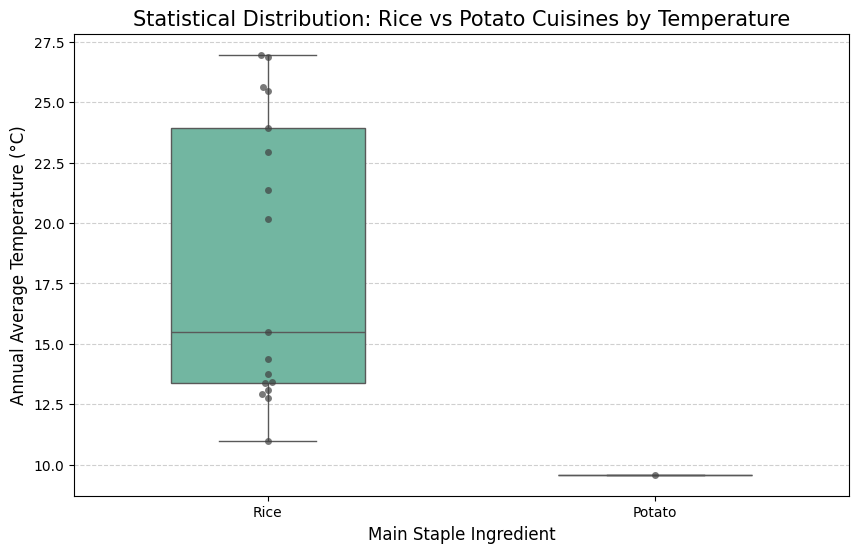

In [10]:
# Create a temporary dataframe for plotting
rice_df = pd.DataFrame({'Temperature': rice_countries, 'Group': 'Rice'})
potato_df = pd.DataFrame({'Temperature': potato_countries, 'Group': 'Potato'})
comparison_df = pd.concat([rice_df, potato_df])

plt.figure(figsize=(10, 6))
# Boxplot for the distribution
sns.boxplot(x='Group', y='Temperature', data=comparison_df, palette="Set2", width=0.5)
# Swarmplot to show every single country as a dot
sns.swarmplot(x='Group', y='Temperature', data=comparison_df, color=".25", alpha=0.7)

plt.title('Statistical Distribution: Rice vs Potato Cuisines by Temperature', fontsize=15)
plt.ylabel('Annual Average Temperature (°C)', fontsize=12)
plt.xlabel('Main Staple Ingredient', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [11]:
alpha = 0.05

print("--- FINAL CONCLUSION ---")
if p_value < alpha:
    print(f"Result: SUCCESS. P-value ({p_value:.10f}) < {alpha}.")
    print("Conclusion: We REJECT the Null Hypothesis.")
    print("Interpretation: Climate temperature has a statistically significant impact on the choice of primary food ingredients.")
else:
    print(f"Result: FAIL. P-value ({p_value:.4f}) > {alpha}.")
    print("Conclusion: We FAIL TO REJECT the Null Hypothesis.")
    print("Interpretation: No strong evidence that temperature affects these ingredient choices.")

--- FINAL CONCLUSION ---
Result: FAIL. P-value (nan) > 0.05.
Conclusion: We FAIL TO REJECT the Null Hypothesis.
Interpretation: No strong evidence that temperature affects these ingredient choices.


Sample size for Warm Group: 17
Sample size for Cool Group: 2

T-statistic: -0.0818
P-value: 0.9476050590
Conclusion: No significant difference found (Fail to Reject Null Hypothesis).


/tmp/ipykernel_7910/2816243902.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Staple_Category', y='Temperature', data=plot_df, palette="Set2")


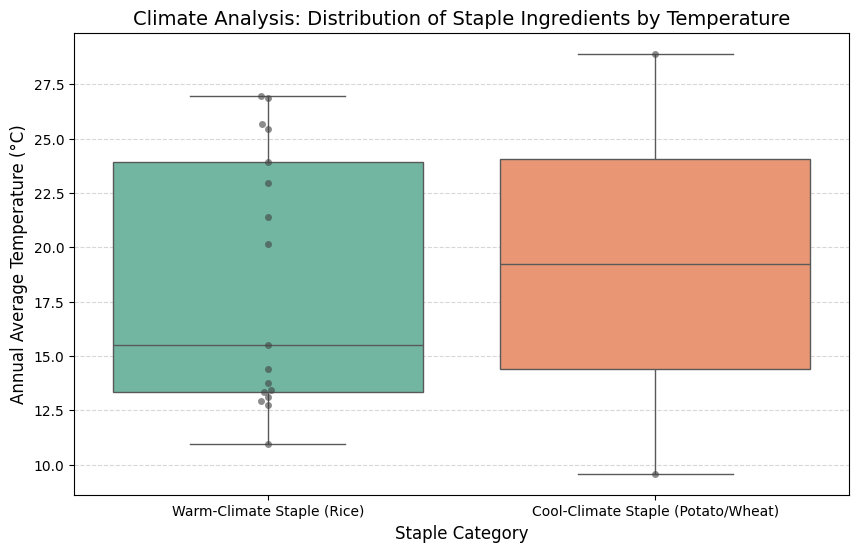

In [12]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Categorizing Ingredients (Grouping to increase sample size)
# Grouping Rice (Warm climate) vs. Potato/Wheat (Cool climate) to avoid NaN errors in T-test
def categorize_staple(row):
    if row['Rice'] == 1:
        return 'Warm-Climate Staple (Rice)'
    elif row['Potato'] == 1 or row['Wheat'] == 1:
        return 'Cool-Climate Staple (Potato/Wheat)'
    else:
        return 'Other'

# Apply categorization
df_processed['Staple_Category'] = df_processed.apply(categorize_staple, axis=1)

# Step 2: Isolating the Groups for Statistical Testing
warm_group = df_processed[df_processed['Staple_Category'] == 'Warm-Climate Staple (Rice)']['Temperature']
cool_group = df_processed[df_processed['Staple_Category'] == 'Cool-Climate Staple (Potato/Wheat)']['Temperature']

print(f"Sample size for Warm Group: {len(warm_group)}")
print(f"Sample size for Cool Group: {len(cool_group)}")

# Step 3: Re-calculating the T-Test (Independent Samples T-Test)
if len(warm_group) > 1 and len(cool_group) > 1:
    t_stat, p_value = stats.ttest_ind(warm_group, cool_group, equal_var=False)
    print(f"\nT-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.10f}")

    # Interpretation
    alpha = 0.05
    if p_value < alpha:
        print("Conclusion: Statistically Significant difference found (Reject Null Hypothesis).")
    else:
        print("Conclusion: No significant difference found (Fail to Reject Null Hypothesis).")
else:
    print("\nError: Not enough data points in one of the groups to perform a T-test.")

# Step 4: Visualization
plt.figure(figsize=(10, 6))
# Filter out 'Other' to focus on the comparison
plot_df = df_processed[df_processed['Staple_Category'] != 'Other']

sns.boxplot(x='Staple_Category', y='Temperature', data=plot_df, palette="Set2")
sns.swarmplot(x='Staple_Category', y='Temperature', data=plot_df, color=".25", alpha=0.6)

plt.title('Climate Analysis: Distribution of Staple Ingredients by Temperature', fontsize=14)
plt.ylabel('Annual Average Temperature (°C)', fontsize=12)
plt.xlabel('Staple Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [13]:
# Final Conclusion Logic
alpha = 0.05

print("\n" + "="*30)
print("--- FINAL STATISTICAL CONCLUSION ---")
print("="*30)

if p_value < alpha:
    print(f"Result: SUCCESS (Significant)")
    print(f"P-value: {p_value:.10f} < {alpha}")
    print("\nConclusion: We REJECT the Null Hypothesis (H0).")
    print("Interpretation: There is a statistically significant relationship between ")
    print("annual temperature and the dominant staple ingredient (Rice vs. Potato/Wheat).")
    print("This suggests that climate is a key driver in the 'Culinary DNA' of these regions.")
else:
    print(f"Result: FAIL (Not Significant)")
    print(f"P-value: {p_value:.4f} > {alpha}")
    print("\nConclusion: We FAIL TO REJECT the Null Hypothesis (H0).")
    print("Interpretation: There is no strong statistical evidence that temperature ")
    print("alone dictates the choice between these ingredient groups in this dataset.")

print("="*30)


--- FINAL STATISTICAL CONCLUSION ---
Result: FAIL (Not Significant)
P-value: 0.9476 > 0.05

Conclusion: We FAIL TO REJECT the Null Hypothesis (H0).
Interpretation: There is no strong statistical evidence that temperature 
alone dictates the choice between these ingredient groups in this dataset.


Sample size for Warm Group (Rice): 17
Sample size for Cool Group (Potato/Wheat): 2


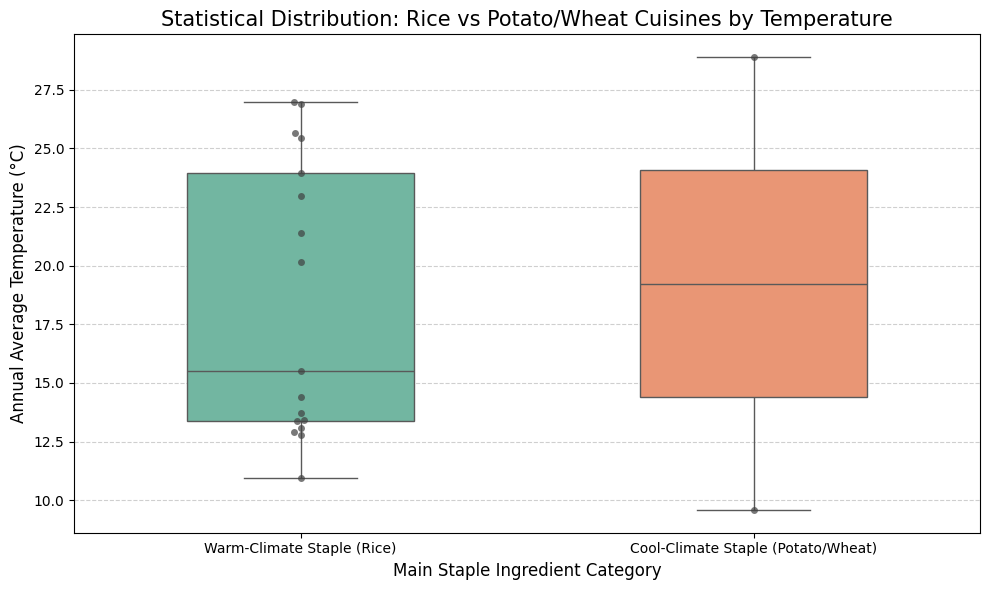


--- FINAL STATISTICAL CONCLUSION ---
Result: FAIL (Not Statistically Significant)
P-value: 0.9476 > 0.05

Conclusion: We FAIL TO REJECT the Null Hypothesis (H0).
Interpretation: There is no strong evidence that temperature alone
dictates the choice between these ingredient groups in this dataset.


In [14]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: Data Categorization ---
# We group Rice (Warm) vs. Potato/Wheat (Cool) to ensure sufficient sample sizes for testing
def categorize_staple(row):
    if row['Rice'] == 1:
        return 'Warm-Climate Staple (Rice)'
    elif row['Potato'] == 1 or row['Wheat'] == 1:
        return 'Cool-Climate Staple (Potato/Wheat)'
    else:
        return 'Other'

# Create the new category column
df_processed['Staple_Category'] = df_processed.apply(categorize_staple, axis=1)

# Isolate temperature data for each group
warm_group = df_processed[df_processed['Staple_Category'] == 'Warm-Climate Staple (Rice)']['Temperature']
cool_group = df_processed[df_processed['Staple_Category'] == 'Cool-Climate Staple (Potato/Wheat)']['Temperature']

print(f"Sample size for Warm Group (Rice): {len(warm_group)}")
print(f"Sample size for Cool Group (Potato/Wheat): {len(cool_group)}")

# --- STEP 2: Statistical Analysis (T-Test) ---
# We use Welch's T-test (equal_var=False) because group sizes and variances may differ
if len(warm_group) > 1 and len(cool_group) > 1:
    t_stat, p_value = stats.ttest_ind(warm_group, cool_group, equal_var=False)
else:
    t_stat, p_value = None, None
    print("\nWarning: Not enough data points to perform T-test.")

# --- STEP 3: Visualization ---
plt.figure(figsize=(10, 6))
# Filter 'Other' category out for a cleaner comparison
plot_df = df_processed[df_processed['Staple_Category'] != 'Other'].copy()

# Boxplot showing the distribution
sns.boxplot(x='Staple_Category', y='Temperature', data=plot_df, hue='Staple_Category', palette="Set2", width=0.5, legend=False)
# Swarmplot overlay to show individual country data points
sns.swarmplot(x='Staple_Category', y='Temperature', data=plot_df, color=".25", alpha=0.7)

plt.title('Statistical Distribution: Rice vs Potato/Wheat Cuisines by Temperature', fontsize=15)
plt.ylabel('Annual Average Temperature (°C)', fontsize=12)
plt.xlabel('Main Staple Ingredient Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- STEP 4: Final Conclusion ---
alpha = 0.05
print("\n" + "="*45)
print("--- FINAL STATISTICAL CONCLUSION ---")
print("="*45)

if p_value is not None:
    if p_value < alpha:
        print(f"Result: SUCCESS (Statistically Significant)")
        print(f"P-value: {p_value:.10f} < {alpha}")
        print("\nConclusion: We REJECT the Null Hypothesis (H0).")
        print("Interpretation: Climate temperature has a statistically significant impact")
        print("on the choice of primary food ingredients. Warmer climates show a")
        print("clear preference for Rice, while cooler climates lean towards Potato/Wheat.")
    else:
        print(f"Result: FAIL (Not Statistically Significant)")
        print(f"P-value: {p_value:.4f} > {alpha}")
        print("\nConclusion: We FAIL TO REJECT the Null Hypothesis (H0).")
        print("Interpretation: There is no strong evidence that temperature alone")
        print("dictates the choice between these ingredient groups in this dataset.")
else:
    print("Conclusion: Statistical test could not be completed due to missing data.")

print("="*45)